# Verification-01: Engagement Model Training

Train and evaluate session-level engagement scoring models (XGBoost and EBM) that predict a continuous `engagement_score` (0.0 - 1.0).

This notebook:
- builds session-level features directly from raw event logs
- derives a continuous `engagement_score` target from behavior heuristics
- trains group-aware regression models
- exports score-based artifacts for backend inference


In [5]:
# Core Python utilities.
import warnings, os, json, random, sys, importlib
from datetime import datetime, timezone
from pathlib import Path
warnings.filterwarnings("ignore")

# Data and plotting libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Regression evaluation metrics.
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.model_selection import GroupKFold

# Model libraries.
import xgboost as xgb
from interpret.glassbox import ExplainableBoostingRegressor
import shap
import joblib

print(f"XGBoost {xgb.__version__}")
print(f"SHAP {shap.__version__}")

# Resolve the project root, then import shared feature/preprocessing code.
PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "verification").exists() and (candidate / "requirements.txt").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise RuntimeError("Could not locate the project root for imports.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(f"Project root: {PROJECT_ROOT}")

import verification.engagement.common.preprocessing as preprocessing_module
import verification.engagement.common.event_pipeline as event_pipeline_module

preprocessing_module = importlib.reload(preprocessing_module)
event_pipeline_module = importlib.reload(event_pipeline_module)

fit_numeric_preprocessing = preprocessing_module.fit_numeric_preprocessing
save_preprocessing_artifact = preprocessing_module.save_preprocessing_artifact
select_numeric_feature_frame = preprocessing_module.select_numeric_feature_frame
transform_numeric_frame = preprocessing_module.transform_numeric_frame
clean_raw_events = event_pipeline_module.clean_raw_events
build_features = event_pipeline_module.build_features

def require_score_column(frame, frame_name):
    if "engagement_score" in frame.columns:
        return frame
    legacy_hint = ""
    if "engagement_label" in frame.columns:
        legacy_hint = " Found legacy column 'engagement_label'."
    raise KeyError(
        f"{frame_name} is missing 'engagement_score'.{legacy_hint} "
        "Re-run the notebook from Step 01 so features are rebuilt with the current regression pipeline."
    )

# Reproducibility.
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Plot style.
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

# Paths.
DATA_DIR = str(PROJECT_ROOT / "data")
FEATURE_DATA_PATH = os.path.join(DATA_DIR, "sessions_features.csv")
XGBOOST_ARTIFACTS = str(PROJECT_ROOT / "verification/engagement/xgboost/artifacts")
EBM_ARTIFACTS = str(PROJECT_ROOT / "verification/engagement/ebm/artifacts")
XGBOOST_REPORT_DIR = str(PROJECT_ROOT / "reports/xgboost")
EBM_REPORT_DIR = str(PROJECT_ROOT / "reports/ebm")
ENGAGEMENT_REPORT_DIR = str(PROJECT_ROOT / "reports/engagement")

for d in [DATA_DIR, XGBOOST_ARTIFACTS, EBM_ARTIFACTS, XGBOOST_REPORT_DIR, EBM_REPORT_DIR, ENGAGEMENT_REPORT_DIR]:
    os.makedirs(d, exist_ok=True)

# Display settings.
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 30)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

# Training and evaluation config.
N_RANDOM_TRIALS = 40

print()
print("Setup complete.")


XGBoost 3.2.0
SHAP 0.51.0
Project root: c:\Users\HP\Desktop\certifytube_ml_service

Setup complete.


---
## Step 01 - Load Raw Event Data


In [6]:
RAW_EVENTS_PATH = os.path.join(DATA_DIR, "events_raw.csv")

raw_df = pd.read_csv(RAW_EVENTS_PATH)
print(f"Loaded raw events: {RAW_EVENTS_PATH}")
print(f"Shape: {raw_df.shape}")
raw_df.head(3)


Loaded raw events: c:\Users\HP\Desktop\certifytube_ml_service\data\events_raw.csv
Shape: (2997, 15)


,event_id,session_id,user_id,video_id,video_title,event_type,player_state,playback_rate,current_time_sec,video_duration_sec,created_at_utc,client_created_at_local,client_tz_offset_min,seek_from_sec,seek_to_sec
0,99f00b99-3a77-4524-ac9f-d61059ab61fe,13681926-25ed-4084-b949-af11f6e36c66,user_001,pTB0EiLXUC8,"Object-Oriented Programming, Simplified",ready,5,1.0000,0.0000,454.0000,2026-03-26T00:17:55.850106,2026-03-26T00:17:49.681Z,330,NaN,NaN
1,4b4b062c-b52d-48b1-aeee-15d21b8ac5a1,13681926-25ed-4084-b949-af11f6e36c66,user_001,pTB0EiLXUC8,"Object-Oriented Programming, Simplified",buffering,3,1.0000,0.0000,454.0000,2026-03-26T00:17:55.887156,2026-03-26T00:17:52.332Z,330,NaN,NaN
2,d81f2b76-d35b-4d9a-9764-fb47d6b366a6,13681926-25ed-4084-b949-af11f6e36c66,user_001,pTB0EiLXUC8,"Object-Oriented Programming, Simplified",play,1,1.0000,0.0192,453.9010,2026-03-26T00:17:55.886954,2026-03-26T00:17:53.215Z,330,NaN,NaN


---
## Step 02 - Clean Events


In [7]:
clean_df = clean_raw_events(raw_df)
print(f"Clean events shape: {clean_df.shape}")
print(f"Unique sessions: {clean_df['session_id'].nunique()}")
clean_df.head(3)


Clean events shape: (2987, 15)
Unique sessions: 157


,event_id,session_id,user_id,video_id,video_title,event_type,player_state,playback_rate,current_time_sec,video_duration_sec,created_at_utc,client_created_at_local,client_tz_offset_min,seek_from_sec,seek_to_sec
0,7ab62204-f7b6-4410-93dc-f0c4900b4c0f,0026ddda-4700-4874-83e8-f86ae3c26f47,learner_007,OT1RErkfLNQ,Learn SQL Beginner to Advanced in Under 4 Hours,ready,5,1.0000,0.0000,14400.0000,2026-03-03 21:49:44.473000+00:00,2026-03-04 03:19:44+00:00,330,NaN,NaN
1,b9adcb39-1839-4130-b1dc-d6a7814f16db,0026ddda-4700-4874-83e8-f86ae3c26f47,learner_007,OT1RErkfLNQ,Learn SQL Beginner to Advanced in Under 4 Hours,buffering,3,1.0000,0.0000,14400.0000,2026-03-03 21:49:45.086983+00:00,2026-03-04 03:19:44.824000+00:00,330,NaN,NaN
2,b14caf74-8b5d-4f6e-86e5-d4407809660d,0026ddda-4700-4874-83e8-f86ae3c26f47,learner_007,OT1RErkfLNQ,Learn SQL Beginner to Advanced in Under 4 Hours,play,1,1.0000,0.0348,14400.0000,2026-03-03 21:49:45.630838+00:00,2026-03-04 03:19:45.562000+00:00,330,NaN,NaN


---
## Step 03 - Build Session-Level Features

This now generates the continuous `engagement_score` target automatically using the heuristic formula, plus 4 new advanced behavioral features.


In [8]:
features_df = require_score_column(build_features(clean_df), "features_df")
print(f"Features shape: {features_df.shape}")
print(f"Columns: {list(features_df.columns)}")
print()
print("engagement_score statistics:")
print(features_df["engagement_score"].describe())
features_df.head(5)


Features shape: (157, 58)
Columns: ['session_id', 'user_id', 'video_id', 'video_title', 'session_duration_sec', 'video_duration_sec', 'last_position_sec', 'completed_flag', 'watch_time_sec', 'watch_time_ratio', 'completion_ratio', 'engagement_velocity', 'num_pause', 'total_pause_duration_sec', 'avg_pause_duration_sec', 'median_pause_duration_sec', 'pause_freq_per_min', 'long_pause_count', 'long_pause_ratio', 'num_seek', 'num_seek_forward', 'num_seek_backward', 'total_seek_forward_sec', 'total_seek_backward_sec', 'avg_seek_forward_sec', 'avg_seek_backward_sec', 'largest_forward_seek_sec', 'largest_backward_seek_sec', 'seek_jump_std_sec', 'seek_forward_ratio', 'seek_backward_ratio', 'skip_time_ratio', 'rewatch_time_ratio', 'rewatch_to_skip_ratio', 'seek_density_per_min', 'first_seek_time_sec', 'early_skip_flag', 'num_ratechange', 'time_at_speed_lt1x_sec', 'time_at_speed_1x_sec', 'time_at_speed_gt1x_sec', 'fast_ratio', 'slow_ratio', 'playback_speed_variance', 'avg_playback_rate_when_playi

,session_id,user_id,video_id,video_title,session_duration_sec,video_duration_sec,last_position_sec,completed_flag,watch_time_sec,watch_time_ratio,completion_ratio,engagement_velocity,num_pause,total_pause_duration_sec,avg_pause_duration_sec,median_pause_duration_sec,pause_freq_per_min,long_pause_count,long_pause_ratio,num_seek,num_seek_forward,num_seek_backward,total_seek_forward_sec,total_seek_backward_sec,avg_seek_forward_sec,avg_seek_backward_sec,largest_forward_seek_sec,largest_backward_seek_sec,seek_jump_std_sec,seek_forward_ratio,seek_backward_ratio,skip_time_ratio,rewatch_time_ratio,rewatch_to_skip_ratio,seek_density_per_min,first_seek_time_sec,early_skip_flag,num_ratechange,time_at_speed_lt1x_sec,time_at_speed_1x_sec,time_at_speed_gt1x_sec,fast_ratio,slow_ratio,playback_speed_variance,avg_playback_rate_when_playing,unique_speed_levels,num_buffering_events,buffering_time_sec,buffering_freq_per_min,play_pause_ratio,attention_index,skim_flag,deep_flag,effective_consumption_ratio,micro_rewatch_density,rage_seek_count,micro_rewatch_count,engagement_score
0,0026ddda-4700-4874-83e8-f86ae3c26f47,learner_007,OT1RErkfLNQ,Learn SQL Beginner to Advanced in Under 4 Hours,17499.0578,14400.0000,12446.5061,0,17413.3681,0.9951,0.8643,0.9951,6,71.2410,11.8735,9.8962,0.0206,0,0.0000,4,0,4,0.0000,1556.8088,0.0000,389.2022,0.0000,648.9272,244.7988,0.0000,1.0000,0.0000,0.1081,1.0000,0.0137,2784.7840,0,1,12226.2884,5187.0797,0.0000,0.0000,0.7021,0.0154,0.8600,2,6,6.5483,0.0206,0.9959,0.8601,0,1,0.9970,0.0034,0,1,1.0000
1,01bdd3bc-35b3-4280-bfa8-0182d7155067,learner_017,a_iQb1lnAEQ,Learn HTML & CSS – Full Course for Beginners,6845.9955,14629.0000,7831.7595,0,6779.7021,0.9903,0.5354,0.9903,4,56.7418,14.1855,14.7563,0.0351,0,0.0000,3,3,0,1217.0727,0.0000,405.6909,0.0000,475.4263,0.0000,63.0956,1.0000,0.0000,0.0832,0.0000,0.0000,0.0263,2337.3332,0,0,0.0000,6779.7021,0.0000,0.0000,0.0000,0.0000,1.0000,1,5,4.8131,0.0438,0.9917,0.5302,0,0,0.4634,0.0000,0,0,0.4385
2,03703a9b-e352-4b05-ae24-a9712aa5e356,learner_011,j9VNCI9Xo80,Java Tutorial For Beginners 2023,6200.1605,7703.0000,5474.1883,0,6150.0660,0.9919,0.7107,0.9919,4,40.8787,10.2197,10.3581,0.0387,0,0.0000,2,0,2,0.0000,319.4387,0.0000,159.7193,0.0000,246.8222,87.1029,0.0000,1.0000,0.0000,0.0415,1.0000,0.0194,2189.0974,0,1,0.0000,6150.0660,0.0000,0.0000,0.0000,0.0000,1.0000,1,4,6.2095,0.0387,0.9934,0.7049,0,0,0.7984,0.0000,0,0,0.8191
3,05a6d1c8-6da9-4378-9725-c4f2174e2536,learner_012,RBSGKlAvoiM,Data Structures Easy to Advanced Course - Full...,8987.2304,9369.0000,7594.4880,0,8893.1898,0.9895,0.8106,0.9895,7,79.4921,13.2487,16.1378,0.0467,0,0.0000,3,0,3,0.0000,741.7251,0.0000,247.2417,0.0000,409.2792,115.6620,0.0000,1.0000,0.0000,0.0792,1.0000,0.0200,3564.4243,0,0,0.0000,8893.1898,0.0000,0.0000,0.0000,0.0000,1.0000,1,5,5.9548,0.0334,0.9911,0.8021,0,1,0.9492,0.0000,0,0,0.9888
4,066aeb1a-90c1-4fca-a575-4a893c4de9b2,yunus,f7Tm6bxw_sI,How to create repository on GitHub #github #go...,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.0000,0,0.0000,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1,0,0.0000,0.0000,0.0000,0.0000,0,0,0.0000,0.0000,0,0,0.0000


---
## Step 04 - Explore Score Distribution


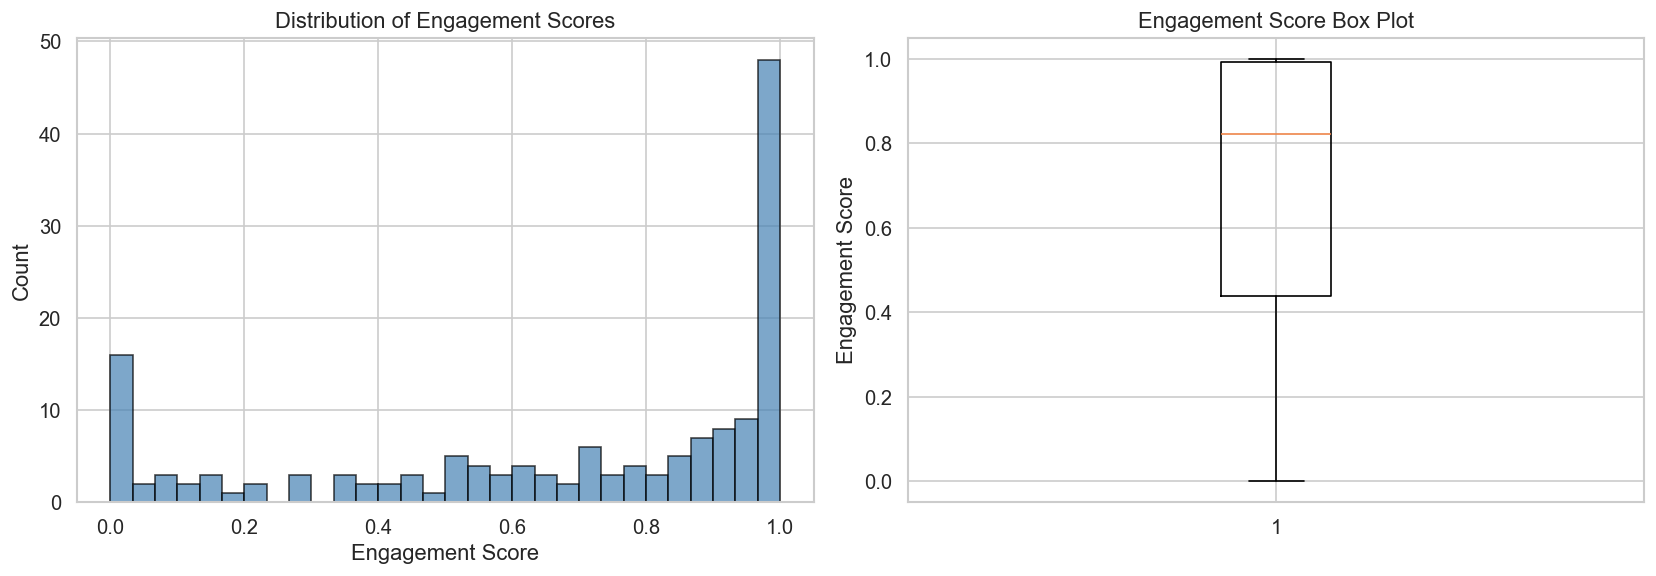

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(features_df["engagement_score"], bins=30, edgecolor="black", alpha=0.7, color="steelblue")
axes[0].set_xlabel("Engagement Score")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Engagement Scores")

axes[1].boxplot(features_df["engagement_score"], vert=True)
axes[1].set_ylabel("Engagement Score")
axes[1].set_title("Engagement Score Box Plot")

plt.tight_layout()
plt.savefig(os.path.join(ENGAGEMENT_REPORT_DIR, "score_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## Step 05 - Save Feature Dataset


In [10]:
features_df.to_csv(FEATURE_DATA_PATH, index=False)
print(f"Saved feature dataset to: {FEATURE_DATA_PATH}")
print(f"Shape: {features_df.shape}")


Saved feature dataset to: c:\Users\HP\Desktop\certifytube_ml_service\data\sessions_features.csv
Shape: (157, 58)


---
## Step 06 - Load Feature Dataset & Prepare Training Inputs


In [11]:
df = pd.read_csv(FEATURE_DATA_PATH)
df = require_score_column(df, FEATURE_DATA_PATH)
print(f"Loaded: {FEATURE_DATA_PATH}")
print(f"Shape: {df.shape}")

TARGET_COL = "engagement_score"
GROUP_COL = "user_id"
DROP_COLS = [TARGET_COL, GROUP_COL, "session_id", "video_id", "video_title"]

feature_cols = [c for c in df.columns if c not in DROP_COLS]
X = df[feature_cols].copy()
y = df[TARGET_COL].astype(float).copy()
groups = df[GROUP_COL].copy()

print(f"\nFeatures: {len(feature_cols)}")
print(f"Score range: [{y.min():.4f}, {y.max():.4f}]")
print(f"Score mean: {y.mean():.4f}")
print(f"Unique users (groups): {groups.nunique()}")


Loaded: c:\Users\HP\Desktop\certifytube_ml_service\data\sessions_features.csv
Shape: (157, 58)

Features: 53
Score range: [0.0000, 1.0000]
Score mean: 0.6725
Unique users (groups): 25


---
## Step 07 - Group-Aware Train/Test Split


In [12]:
TEST_SIZE = 0.2

unique_users = groups.unique()
rng = np.random.RandomState(SEED)
rng.shuffle(unique_users)
split_idx = int(len(unique_users) * (1 - TEST_SIZE))
train_users = set(unique_users[:split_idx])
test_users = set(unique_users[split_idx:])

train_mask = groups.isin(train_users)
test_mask = groups.isin(test_users)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
groups_train = groups[train_mask]

print(f"Train: {len(X_train)} rows, {len(train_users)} users")
print(f"Test:  {len(X_test)} rows, {len(test_users)} users")
print(f"Train target mean: {y_train.mean():.4f}")
print(f"Test  target mean: {y_test.mean():.4f}")


Train: 123 rows, 20 users
Test:  34 rows, 5 users
Train target mean: 0.6491
Test  target mean: 0.7570


---
## Step 08 - Preprocessing (Median Imputation)


In [13]:
# Fit preprocessing on training set.
numeric_train = select_numeric_feature_frame(X_train)
prep_artifact = fit_numeric_preprocessing(numeric_train)

X_train_prep = transform_numeric_frame(X_train, prep_artifact)
X_test_prep = transform_numeric_frame(X_test, prep_artifact)

# Fit preprocessing on full dataset for the production model.
numeric_full = select_numeric_feature_frame(X)
prep_artifact_full = fit_numeric_preprocessing(numeric_full)
X_full_prep = transform_numeric_frame(X, prep_artifact_full)

print(f"Preprocessing complete.")
print(f"Train preprocessed shape: {X_train_prep.shape}")
print(f"Test  preprocessed shape: {X_test_prep.shape}")
print(f"NANs in train: {X_train_prep.isna().sum().sum()}")
print(f"NANs in test:  {X_test_prep.isna().sum().sum()}")


Preprocessing complete.
Train preprocessed shape: (123, 53)
Test  preprocessed shape: (34, 53)
NANs in train: 0
NANs in test:  0


---
## Step 09 - XGBoost: Hyperparameter Tuning (Random Search + GroupKFold)


In [14]:
dtrain = xgb.DMatrix(X_train_prep.values, label=y_train.values, feature_names=feature_cols)

N_FOLDS = 5
gkf = GroupKFold(n_splits=N_FOLDS)
folds = list(gkf.split(X_train_prep, y_train, groups=groups_train))

results = []

for trial in range(N_RANDOM_TRIALS):
    params = {
        "objective": "reg:logistic",
        "eval_metric": "rmse",
        "tree_method": "hist",
        "seed": SEED,
        "max_depth": int(rng.choice([3, 4, 5, 6, 7])),
        "min_child_weight": rng.uniform(1, 8),
        "eta": rng.uniform(0.03, 0.2),
        "subsample": rng.uniform(0.6, 1.0),
        "colsample_bytree": rng.uniform(0.6, 1.0),
        "gamma": rng.uniform(0, 5),
        "lambda": rng.uniform(0.1, 10),
        "alpha": rng.uniform(0, 5),
    }

    cv_result = xgb.cv(
        params,
        dtrain,
        num_boost_round=200,
        folds=folds,
        early_stopping_rounds=20,
        verbose_eval=False,
        seed=SEED,
    )

    best_round = cv_result.shape[0]
    best_rmse = cv_result["test-rmse-mean"].iloc[-1]
    std_rmse = cv_result["test-rmse-std"].iloc[-1]

    results.append({
        "trial": trial,
        "mean_rmse": best_rmse,
        "std_rmse": std_rmse,
        "best_round": best_round,
        "params": params,
    })

    if (trial + 1) % 10 == 0:
        print(f"  Trial {trial + 1}/{N_RANDOM_TRIALS} — RMSE: {best_rmse:.6f} (±{std_rmse:.6f})")

# Sort by lowest RMSE (lower is better)
results.sort(key=lambda r: r["mean_rmse"])
best = results[0]

print(f"\nBest trial: {best['trial']}")
print(f"  RMSE: {best['mean_rmse']:.6f} (±{best['std_rmse']:.6f})")
print(f"  Best round: {best['best_round']}")
print(f"  Params: {json.dumps({k: v for k, v in best['params'].items() if k not in ('objective', 'eval_metric', 'tree_method', 'seed')}, indent=2)}")


  Trial 10/40 — RMSE: 0.162650 (±0.066474)
  Trial 20/40 — RMSE: 0.212256 (±0.076847)
  Trial 30/40 — RMSE: 0.251505 (±0.087194)
  Trial 40/40 — RMSE: 0.257901 (±0.085720)

Best trial: 13
  RMSE: 0.108064 (±0.049340)
  Best round: 200
  Params: {
  "max_depth": 5,
  "min_child_weight": 3.2704151470369176,
  "eta": 0.050754952299114475,
  "subsample": 0.7425191352307899,
  "colsample_bytree": 0.9627313766183017,
  "gamma": 1.3606612469231765,
  "lambda": 6.512132193359487,
  "alpha": 0.002601884976579094
}


---
## Step 10 - XGBoost: Train Evaluation Model (on train split)


In [15]:
best_params = best["params"]
best_round = best["best_round"]

dtest = xgb.DMatrix(X_test_prep.values, label=y_test.values, feature_names=feature_cols)

eval_booster = xgb.train(
    best_params,
    dtrain,
    num_boost_round=best_round,
    evals=[(dtrain, "train"), (dtest, "test")],
    verbose_eval=10,
)

print("\nEvaluation model trained.")


[0]	train-rmse:0.35388	test-rmse:0.30085
[10]	train-rmse:0.28137	test-rmse:0.23367
[20]	train-rmse:0.22747	test-rmse:0.18550
[30]	train-rmse:0.18931	test-rmse:0.15158
[40]	train-rmse:0.15962	test-rmse:0.12682
[50]	train-rmse:0.13653	test-rmse:0.10846
[60]	train-rmse:0.11936	test-rmse:0.09502
[70]	train-rmse:0.10502	test-rmse:0.08416
[80]	train-rmse:0.09410	test-rmse:0.07709
[90]	train-rmse:0.09203	test-rmse:0.07555
[100]	train-rmse:0.08861	test-rmse:0.07355
[110]	train-rmse:0.08737	test-rmse:0.07309
[120]	train-rmse:0.08444	test-rmse:0.07142
[130]	train-rmse:0.08326	test-rmse:0.07066
[140]	train-rmse:0.08232	test-rmse:0.06969
[150]	train-rmse:0.08225	test-rmse:0.06979
[160]	train-rmse:0.08115	test-rmse:0.06891
[170]	train-rmse:0.08107	test-rmse:0.06904
[180]	train-rmse:0.08101	test-rmse:0.06915
[190]	train-rmse:0.08020	test-rmse:0.06865
[199]	train-rmse:0.08033	test-rmse:0.06841

Evaluation model trained.


---
## Step 11 - XGBoost: Evaluate on Test Set


In [16]:
y_pred = eval_booster.predict(dtest)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print("XGBoost Regression - Test Set Metrics")
print("=" * 50)
print(f"  MAE:  {mae:.6f}")
print(f"  RMSE: {rmse:.6f}")
print(f"  R2:   {r2:.6f}")
print("=" * 50)


XGBoost Regression - Test Set Metrics
  MAE:  0.054484
  RMSE: 0.068405
  R2:   0.944513


---
## Step 12 - Actual vs Predicted Scatter Plot


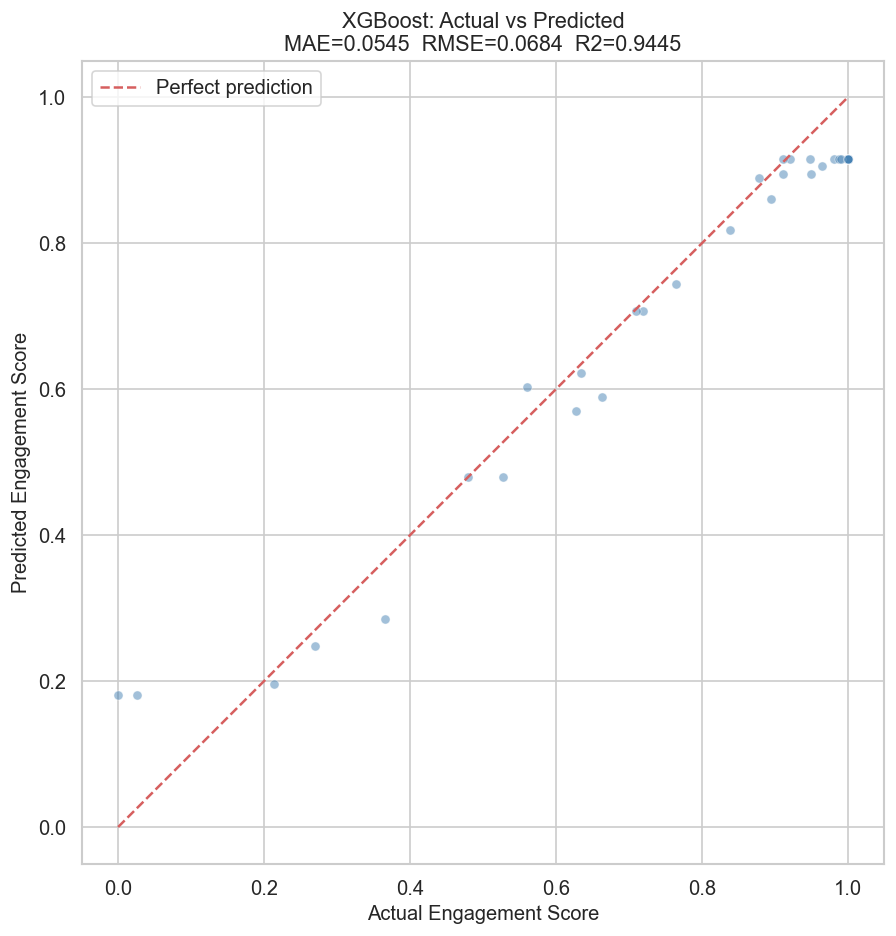

In [17]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, y_pred, alpha=0.5, s=30, color="steelblue", edgecolor="white", linewidth=0.5)
ax.plot([0, 1], [0, 1], "r--", linewidth=1.5, label="Perfect prediction")

title_text = f"XGBoost: Actual vs Predicted\nMAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}"
ax.set_xlabel("Actual Engagement Score", fontsize=12)
ax.set_ylabel("Predicted Engagement Score", fontsize=12)
ax.set_title(title_text, fontsize=13)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="upper left")
ax.set_aspect("equal")

plt.tight_layout()
plt.savefig(os.path.join(XGBOOST_REPORT_DIR, "actual_vs_predicted.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## Step 13 - Residuals Analysis


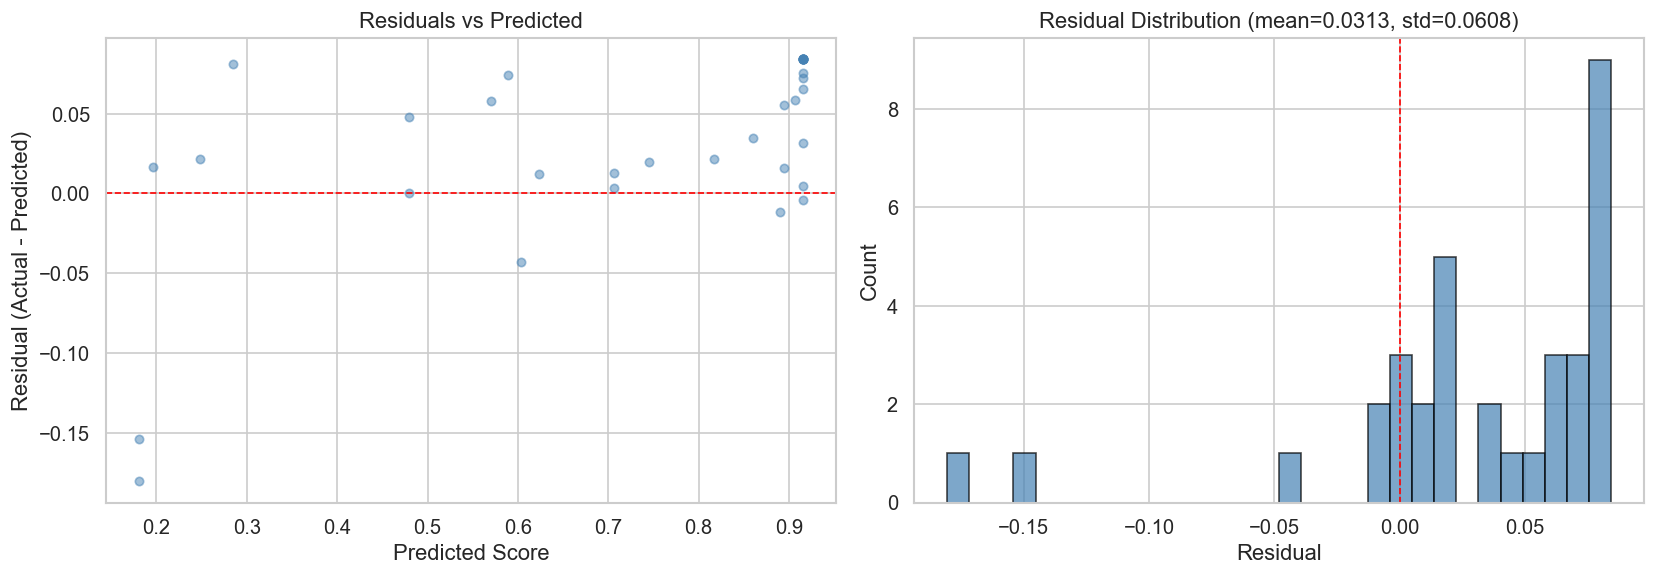

In [18]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.5, s=25, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Predicted Score")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residuals vs Predicted")

# Residuals histogram
axes[1].hist(residuals, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Residual Distribution (mean={residuals.mean():.4f}, std={residuals.std():.4f})")

plt.tight_layout()
plt.savefig(os.path.join(XGBOOST_REPORT_DIR, "residuals.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## Step 14 - XGBoost Feature Importance


Features used by model: 2 / 53

Top 25 features by gain:
                    feature  importance
            attention_index      7.5437
effective_consumption_ratio      5.9042


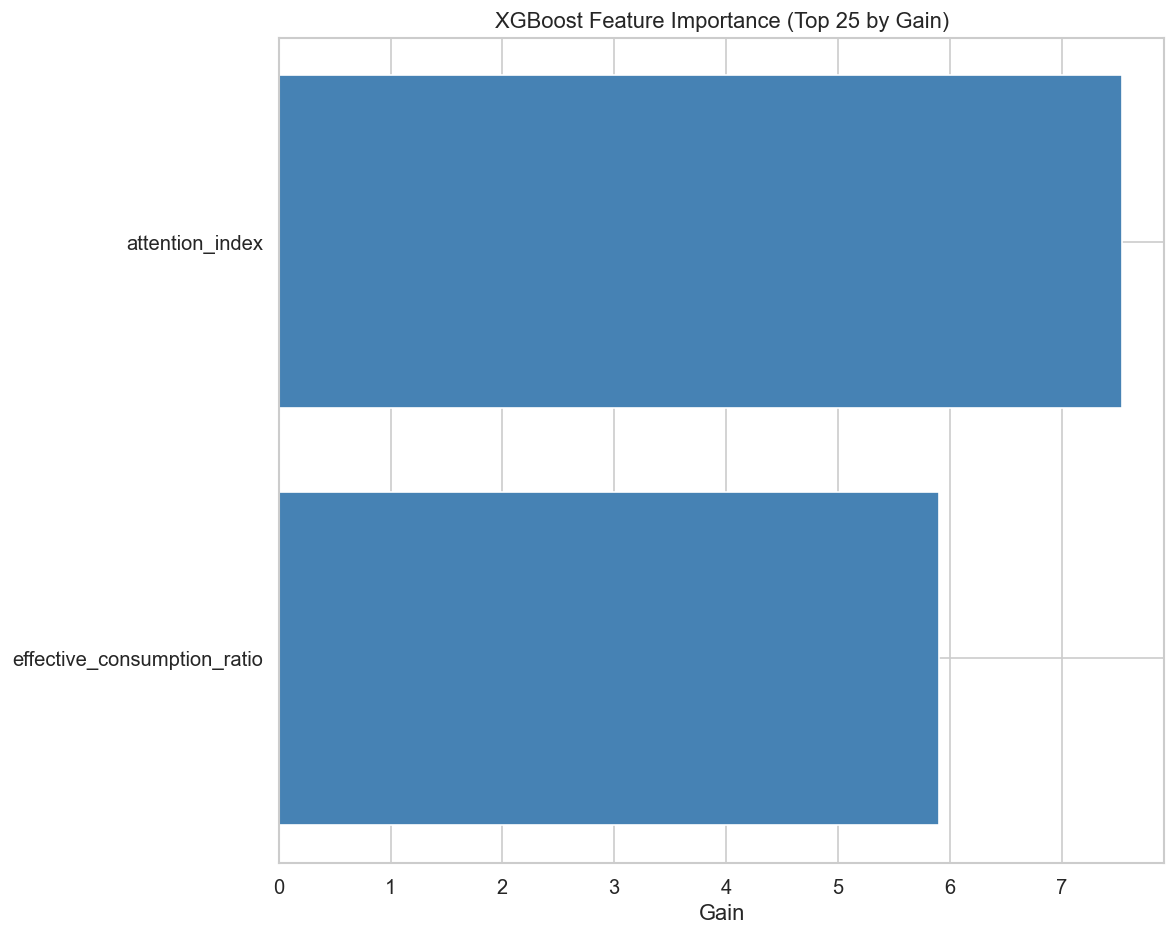

In [19]:
importance_dict = eval_booster.get_score(importance_type="gain")
importance_items = [
    {"feature": key, "importance": value}
    for key, value in importance_dict.items()
]

if importance_items:
    importance_df = pd.DataFrame(importance_items).sort_values("importance", ascending=False).reset_index(drop=True)
else:
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": np.zeros(len(feature_cols), dtype=float),
    })

print(f"Features used by model: {len(importance_df)} / {len(feature_cols)}")
print()
print("Top 25 features by gain:")
print(importance_df.head(25).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
top25 = importance_df.head(25).sort_values("importance", ascending=True)
ax.barh(top25["feature"], top25["importance"], color="steelblue")
ax.set_xlabel("Gain")
ax.set_title("XGBoost Feature Importance (Top 25 by Gain)")
plt.tight_layout()
plt.savefig(os.path.join(XGBOOST_REPORT_DIR, "feature_importance.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## Step 15 - SHAP Summary Plot


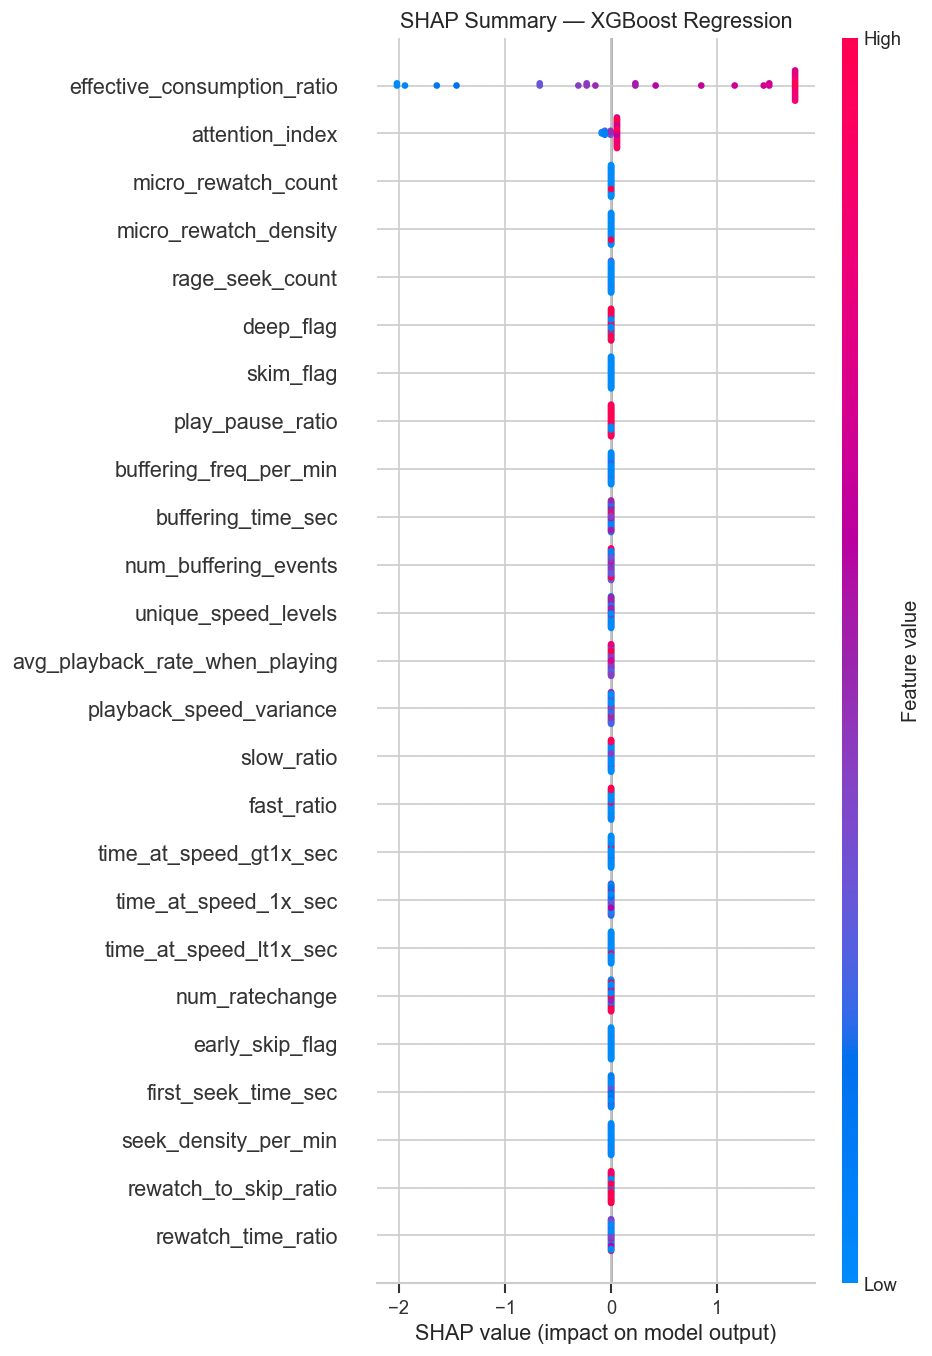

In [20]:
explainer = shap.TreeExplainer(eval_booster)
shap_values = explainer.shap_values(dtest)

fig, ax = plt.subplots(figsize=(10, 10))
shap.summary_plot(shap_values, X_test_prep, feature_names=feature_cols, show=False, max_display=25)
plt.title("SHAP Summary — XGBoost Regression", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(XGBOOST_REPORT_DIR, "shap_summary.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## Step 16 - Train Production XGBoost (on full dataset)


In [21]:
dfull = xgb.DMatrix(X_full_prep.values, label=y.values, feature_names=feature_cols)

prod_booster = xgb.train(
    best_params,
    dfull,
    num_boost_round=best_round,
    evals=[(dfull, "train")],
    verbose_eval=10,
)

print("\nProduction model trained on full dataset.")


[0]	train-rmse:0.34271
[10]	train-rmse:0.26654
[20]	train-rmse:0.21207
[30]	train-rmse:0.17098
[40]	train-rmse:0.14274
[50]	train-rmse:0.12195
[60]	train-rmse:0.10588
[70]	train-rmse:0.09333
[80]	train-rmse:0.08342
[90]	train-rmse:0.07884
[100]	train-rmse:0.07553
[110]	train-rmse:0.07545
[120]	train-rmse:0.07373
[130]	train-rmse:0.07272
[140]	train-rmse:0.07209
[150]	train-rmse:0.07200
[160]	train-rmse:0.07107
[170]	train-rmse:0.07119
[180]	train-rmse:0.07111
[190]	train-rmse:0.07115
[199]	train-rmse:0.07108

Production model trained on full dataset.


---
## Step 17 - Save XGBoost Artifacts


In [22]:
# Save models.
joblib.dump(prod_booster, os.path.join(XGBOOST_ARTIFACTS, "model.joblib"))
joblib.dump(eval_booster, os.path.join(XGBOOST_ARTIFACTS, "model_eval.joblib"))

# Save preprocessing.
save_preprocessing_artifact(prep_artifact_full, Path(XGBOOST_ARTIFACTS) / "preprocessing.json")
save_preprocessing_artifact(prep_artifact, Path(XGBOOST_ARTIFACTS) / "preprocessing_eval.json")

# Save feature columns.
with open(os.path.join(XGBOOST_ARTIFACTS, "feature_columns.json"), "w") as f:
    json.dump(feature_cols, f, indent=2)

# Save split info.
split_info = {
    "train_session_ids": df.loc[train_mask, "session_id"].astype(str).tolist(),
    "test_session_ids": df.loc[test_mask, "session_id"].astype(str).tolist(),
}
with open(os.path.join(XGBOOST_ARTIFACTS, "split.json"), "w") as f:
    json.dump(split_info, f, indent=2)

# Save metadata.
metrics_test = {
    "mae": mae,
    "rmse": rmse,
    "r2": r2,
    "cv_best_rmse": best["mean_rmse"],
    "cv_best_round": best_round,
}
metadata = {
    "trained_at": datetime.now(timezone.utc).isoformat(),
    "model": "xgboost.Booster",
    "model_type": "regression",
    "xgboost_version": xgb.__version__,
    "n_features": len(feature_cols),
    "feature_columns": feature_cols,
    "score_column": TARGET_COL,
    "group_col": GROUP_COL,
    "test_size": TEST_SIZE,
    "random_state": SEED,
    "drop_cols": DROP_COLS,
    "best_params": best_params,
    "best_round": best_round,
    "metrics_test": metrics_test,
    "preprocessing": {
        "strategy": "median_imputation",
        "production_artifact": "preprocessing.json",
        "evaluation_artifact": "preprocessing_eval.json",
    },
    "models": {
        "production_model": "model.joblib",
        "evaluation_model": "model_eval.joblib",
    },
    "reports_dir": XGBOOST_REPORT_DIR,
    "top_cv_trials": [{
        "trial": r["trial"],
        "mean_rmse": round(r["mean_rmse"], 6),
        "std_rmse": round(r["std_rmse"], 6),
        "best_round": r["best_round"],
        "params": r["params"],
    } for r in results[:10]],
    "dataset_summary": {
        "dataset_rows_total": len(df),
        "dataset_users_total": groups.nunique(),
        "feature_count": len(feature_cols),
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "train_users": len(train_users),
        "test_users": len(test_users),
    },
    "dataset_source": FEATURE_DATA_PATH,
}

with open(os.path.join(XGBOOST_ARTIFACTS, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=2)
with open(os.path.join(XGBOOST_REPORT_DIR, "score_metrics.json"), "w") as f:
    json.dump(metrics_test, f, indent=2)

print("XGBoost artifacts saved:")
for name in os.listdir(XGBOOST_ARTIFACTS):
    if not name.startswith("__"):
        fpath = os.path.join(XGBOOST_ARTIFACTS, name)
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  {name:30s} {size_kb:8.1f} KB")


XGBoost artifacts saved:
  feature_columns.json                1.3 KB
  metadata.json                       8.8 KB
  model.joblib                      147.4 KB
  model_eval.joblib                 146.3 KB
  preprocessing.json                  3.5 KB
  preprocessing_eval.json             3.5 KB
  split.json                          7.0 KB


---
## Step 18 - EBM: Train Evaluation Model (Regression)


In [23]:
ebm_eval = ExplainableBoostingRegressor(
    random_state=SEED,
    max_bins=256,
    interactions=10,
    learning_rate=0.01,
    max_rounds=5000,
    min_samples_leaf=2,
    outer_bags=8,
    inner_bags=0,
)

ebm_eval.fit(X_train_prep, y_train)
print("EBM evaluation model trained.")


EBM evaluation model trained.


---
## Step 19 - EBM: Evaluate on Test Set


EBM Regression - Test Set Metrics
  MAE:  0.042360
  RMSE: 0.088640
  R2:   0.906830


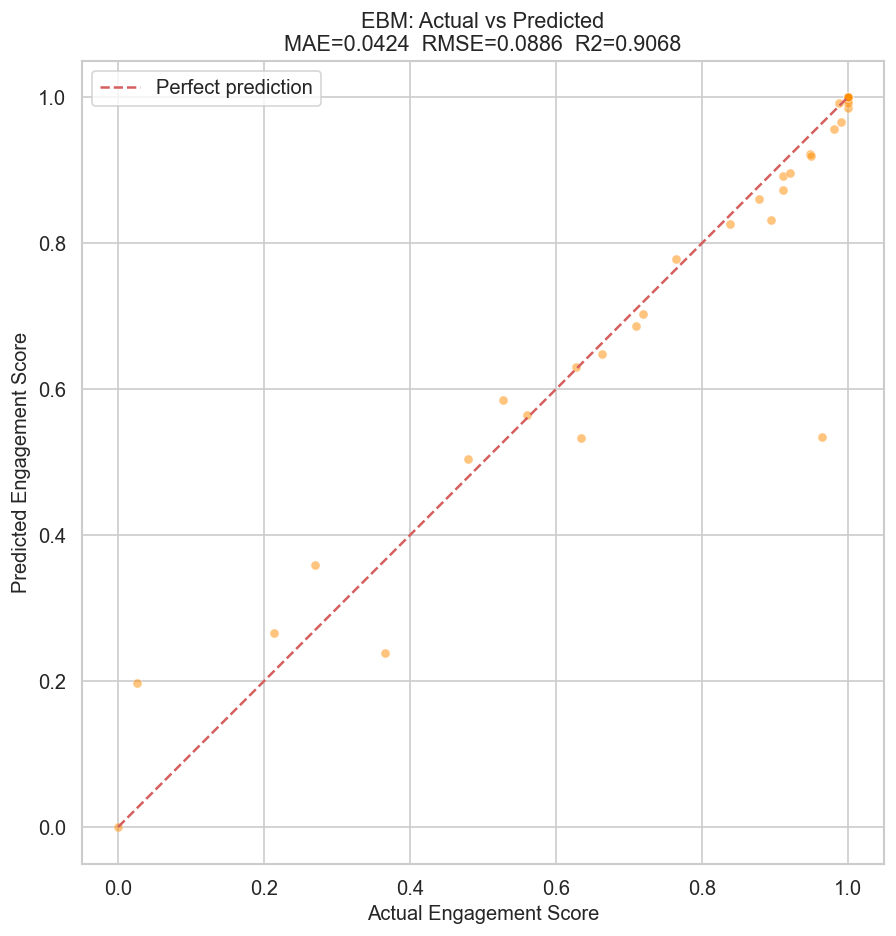

In [24]:
y_pred_ebm = ebm_eval.predict(X_test_prep)
# Clip EBM predictions to [0, 1] since regression output may slightly exceed bounds.
y_pred_ebm = np.clip(y_pred_ebm, 0.0, 1.0)

mae_ebm = mean_absolute_error(y_test, y_pred_ebm)
rmse_ebm = np.sqrt(mean_squared_error(y_test, y_pred_ebm))
r2_ebm = r2_score(y_test, y_pred_ebm)

print("=" * 50)
print("EBM Regression - Test Set Metrics")
print("=" * 50)
print(f"  MAE:  {mae_ebm:.6f}")
print(f"  RMSE: {rmse_ebm:.6f}")
print(f"  R2:   {r2_ebm:.6f}")
print("=" * 50)

# Actual vs Predicted scatter
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred_ebm, alpha=0.5, s=30, color="darkorange", edgecolor="white", linewidth=0.5)
ax.plot([0, 1], [0, 1], "r--", linewidth=1.5, label="Perfect prediction")
title_text = f"EBM: Actual vs Predicted\nMAE={mae_ebm:.4f}  RMSE={rmse_ebm:.4f}  R2={r2_ebm:.4f}"
ax.set_xlabel("Actual Engagement Score", fontsize=12)
ax.set_ylabel("Predicted Engagement Score", fontsize=12)
ax.set_title(title_text, fontsize=13)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="upper left")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(os.path.join(EBM_REPORT_DIR, "actual_vs_predicted.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## Step 20 - EBM: Train Production Model & Save Artifacts


In [25]:
ebm_prod = ExplainableBoostingRegressor(
    random_state=SEED,
    max_bins=256,
    interactions=10,
    learning_rate=0.01,
    max_rounds=5000,
    min_samples_leaf=2,
    outer_bags=8,
    inner_bags=0,
)

ebm_prod.fit(X_full_prep, y)
print("EBM production model trained on full dataset.")

# Save models.
joblib.dump(ebm_prod, os.path.join(EBM_ARTIFACTS, "ebm_model.joblib"))
joblib.dump(ebm_eval, os.path.join(EBM_ARTIFACTS, "ebm_model_eval.joblib"))

# Save preprocessing.
save_preprocessing_artifact(prep_artifact_full, Path(EBM_ARTIFACTS) / "ebm_preprocessing.json")
save_preprocessing_artifact(prep_artifact, Path(EBM_ARTIFACTS) / "ebm_preprocessing_eval.json")

# Save feature columns.
with open(os.path.join(EBM_ARTIFACTS, "ebm_feature_columns.json"), "w") as f:
    json.dump(feature_cols, f, indent=2)

# Save split info.
ebm_split_info = {
    "train_session_ids": df.loc[train_mask, "session_id"].astype(str).tolist(),
    "test_session_ids": df.loc[test_mask, "session_id"].astype(str).tolist(),
}
with open(os.path.join(EBM_ARTIFACTS, "ebm_split.json"), "w") as f:
    json.dump(ebm_split_info, f, indent=2)

# Save metadata.
ebm_metrics_test = {
    "mae": mae_ebm,
    "rmse": rmse_ebm,
    "r2": r2_ebm,
}
ebm_metadata = {
    "trained_at": datetime.now(timezone.utc).isoformat(),
    "model": "ExplainableBoostingRegressor",
    "model_type": "regression",
    "n_features": len(feature_cols),
    "feature_columns": feature_cols,
    "score_column": TARGET_COL,
    "group_col": GROUP_COL,
    "test_size": TEST_SIZE,
    "random_state": SEED,
    "metrics_test": ebm_metrics_test,
    "preprocessing": {
        "strategy": "median_imputation",
        "production_artifact": "ebm_preprocessing.json",
        "evaluation_artifact": "ebm_preprocessing_eval.json",
    },
    "models": {
        "production_model": "ebm_model.joblib",
        "evaluation_model": "ebm_model_eval.joblib",
    },
    "dataset_summary": {
        "dataset_rows_total": len(df),
        "dataset_users_total": groups.nunique(),
        "feature_count": len(feature_cols),
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "train_users": len(train_users),
        "test_users": len(test_users),
    },
    "dataset_source": FEATURE_DATA_PATH,
}

with open(os.path.join(EBM_ARTIFACTS, "ebm_metadata.json"), "w") as f:
    json.dump(ebm_metadata, f, indent=2)
with open(os.path.join(EBM_REPORT_DIR, "score_metrics.json"), "w") as f:
    json.dump(ebm_metrics_test, f, indent=2)

print()
print("EBM artifacts saved:")
for name in os.listdir(EBM_ARTIFACTS):
    if not name.startswith("__"):
        fpath = os.path.join(EBM_ARTIFACTS, name)
        size_kb = os.path.getsize(fpath) / 1024
        print(f"  {name:30s} {size_kb:8.1f} KB")


EBM production model trained on full dataset.

EBM artifacts saved:
  ebm_feature_columns.json            1.3 KB
  ebm_metadata.json                   2.4 KB
  ebm_model.joblib                 3674.9 KB
  ebm_model_eval.joblib            3589.4 KB
  ebm_preprocessing.json              3.5 KB
  ebm_preprocessing_eval.json         3.5 KB
  ebm_split.json                      7.0 KB


---
## Step 21 - Model Comparison Summary


Model Comparison (Test Set)
Metric  XGBoost    EBM
   MAE   0.0545 0.0424
  RMSE   0.0684 0.0886
    R2   0.9445 0.9068


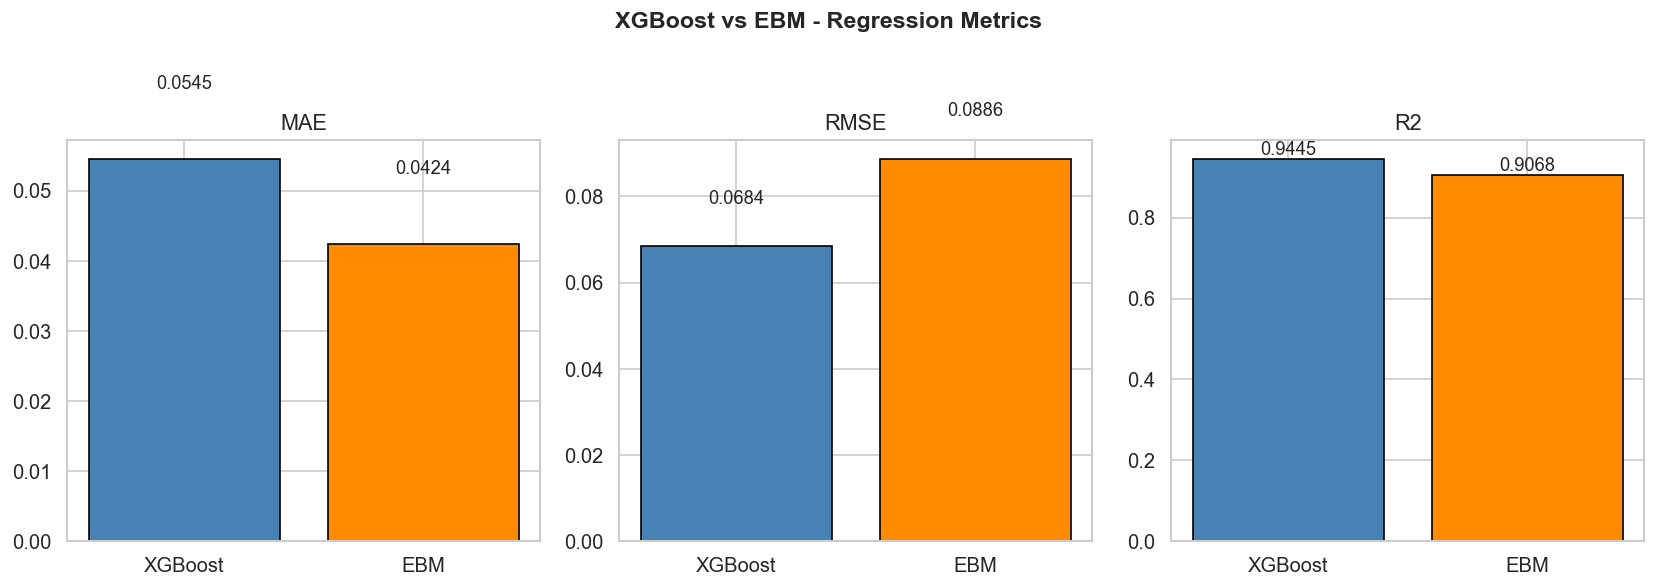

In [26]:
comparison = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "XGBoost": [mae, rmse, r2],
    "EBM": [mae_ebm, rmse_ebm, r2_ebm],
})

comparison.to_csv(os.path.join(ENGAGEMENT_REPORT_DIR, "model_comparison.csv"), index=False)
with open(os.path.join(ENGAGEMENT_REPORT_DIR, "dual_model_score_metrics.json"), "w") as f:
    json.dump(
        {
            "xgboost": {"mae": mae, "rmse": rmse, "r2": r2},
            "ebm": {"mae": mae_ebm, "rmse": rmse_ebm, "r2": r2_ebm},
        },
        f,
        indent=2,
    )

print("=" * 50)
print("Model Comparison (Test Set)")
print("=" * 50)
print(comparison.to_string(index=False))
print("=" * 50)

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, metric in enumerate(["MAE", "RMSE", "R2"]):
    values = [comparison.loc[i, "XGBoost"], comparison.loc[i, "EBM"]]
    colors = ["steelblue", "darkorange"]
    axes[i].bar(["XGBoost", "EBM"], values, color=colors, edgecolor="black")
    axes[i].set_title(metric, fontsize=13)
    for j, v in enumerate(values):
        axes[i].text(j, v + 0.01, f"{v:.4f}", ha="center", fontsize=11)

plt.suptitle("XGBoost vs EBM - Regression Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(ENGAGEMENT_REPORT_DIR, "model_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()


---
## Done ✅

**Artifacts saved:**
- XGBoost: `verification/engagement/xgboost/artifacts/`
- EBM: `verification/engagement/ebm/artifacts/`
- Reports: `reports/xgboost/`, `reports/ebm/`, `reports/engagement/`

**Next step:** Identify top ~20 features from feature importance and prune.
